In [6]:
import sqlite3
import pandas as pd
import os

project_path = r"D:\mf_project"
os.chdir(project_path)

conn = sqlite3.connect('bluestock_mf.db')

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in DB:", cursor.fetchall())

df = pd.read_sql_query("SELECT * FROM fact_nav", conn)
conn.close()

print("Data head:")
print(df.head())

Tables in DB: [('fact_aum',), ('dim_date',), ('fact_nav',), ('fact_transactions',), ('fact_performance',)]
Data head:
   scheme_code                        date      nav
0       118632  2013-01-02 00:00:00.000000  14.5671
1       118632  2013-01-03 00:00:00.000000  13.8247
2       118632  2013-01-04 00:00:00.000000  13.6324
3       118632  2013-01-05 00:00:00.000000  13.6324
4       118632  2013-01-06 00:00:00.000000  13.6324


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

os.chdir(r"D:\mf_project")

nav_pivot = df.pivot(index='date', columns='scheme_code', values='nav')
nav_pivot.index = pd.to_datetime(nav_pivot.index)

daily_returns = nav_pivot.pct_change().dropna()

benchmark_nifty100 = daily_returns.columns[0]
benchmark_nifty50 = daily_returns.columns[1] if len(daily_returns.columns) > 1 else daily_returns.columns[0]

rf = 0.065 / 252

metrics_list = []

for fund in nav_pivot.columns:
    fund_nav = nav_pivot[fund].dropna()
    fund_ret = daily_returns[fund].dropna()
    bench_ret = daily_returns[benchmark_nifty100].dropna()
    
    align_ret, align_bench = fund_ret.align(bench_ret, join='inner')
    
    total_days = (fund_nav.index[-1] - fund_nav.index[0]).days
    cagr_overall = (fund_nav.iloc[-1] / fund_nav.iloc[0]) ** (365 / total_days) - 1 if total_days > 0 else 0
    
    days_1y = 365
    cagr_1y = (fund_nav.iloc[-1] / fund_nav.iloc[-252]) ** (365 / days_1y) - 1 if len(fund_nav) >= 252 else np.nan
    
    days_3y = 365 * 3
    cagr_3y = (fund_nav.iloc[-1] / fund_nav.iloc[-756]) ** (365 / days_3y) - 1 if len(fund_nav) >= 756 else np.nan
    
    days_5y = 365 * 5
    cagr_5y = (fund_nav.iloc[-1] / fund_nav.iloc[-1260]) ** (365 / days_5y) - 1 if len(fund_nav) >= 1260 else np.nan
    
    excess_ret = align_ret - rf
    sharpe = (excess_ret.mean() / align_ret.std()) * np.sqrt(252) if align_ret.std() != 0 else 0
    
    downside = align_ret[align_ret < 0]
    sortino = (excess_ret.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 and downside.std() != 0 else 0
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(align_bench, align_ret)
    alpha = intercept * 252
    beta = slope
    
    rolling_max = fund_nav.cummax()
    drawdown = (fund_nav / rolling_max) - 1
    max_dd = drawdown.min()
    
    tracking_error = (align_ret - align_bench).std() * np.sqrt(252)
    
    expense_ratio = np.random.uniform(0.005, 0.02)
    
    metrics_list.append({
        'Scheme_Code': fund,
        'CAGR_1Y': cagr_1y,
        'CAGR_3Y': cagr_3y,
        'CAGR_5Y': cagr_5y,
        'CAGR_Overall': cagr_overall,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Alpha': alpha,
        'Beta': beta,
        'Max_Drawdown': max_dd,
        'Expense_Ratio': expense_ratio,
        'Tracking_Error': tracking_error
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df['CAGR_3Y'] = metrics_df['CAGR_3Y'].fillna(metrics_df['CAGR_Overall'])

metrics_df.to_csv('alpha_beta.csv', index=False)

metrics_df['Rank_Return'] = metrics_df['CAGR_3Y'].rank(pct=True)
metrics_df['Rank_Sharpe'] = metrics_df['Sharpe'].rank(pct=True)
metrics_df['Rank_Alpha'] = metrics_df['Alpha'].rank(pct=True)
metrics_df['Rank_ER'] = metrics_df['Expense_Ratio'].rank(pct=True, ascending=False)
metrics_df['Rank_DD'] = metrics_df['Max_Drawdown'].rank(pct=True, ascending=False)

metrics_df['Score'] = (
    0.30 * metrics_df['Rank_Return'] +
    0.25 * metrics_df['Rank_Sharpe'] +
    0.20 * metrics_df['Rank_Alpha'] +
    0.15 * metrics_df['Rank_ER'] +
    0.10 * metrics_df['Rank_DD']
) * 100

metrics_df = metrics_df.sort_values(by='Score', ascending=False)
metrics_df.to_csv('fund_scorecard.csv', index=False)

top_5_funds = metrics_df.head(5)['Scheme_Code'].tolist()

plt.figure(figsize=(14, 7))

for fund in top_5_funds:
    fund_nav = nav_pivot[fund].dropna()
    fund_nav_normalized = fund_nav / fund_nav.iloc[0] * 100
    plt.plot(fund_nav_normalized.index, fund_nav_normalized, label=str(fund))

bench100_nav = nav_pivot[benchmark_nifty100].dropna()
bench100_normalized = bench100_nav / bench100_nav.iloc[0] * 100
plt.plot(bench100_normalized.index, bench100_normalized, label='Nifty 100 Proxy', linestyle='dashed', color='black')

bench50_nav = nav_pivot[benchmark_nifty50].dropna()
bench50_normalized = bench50_nav / bench50_nav.iloc[0] * 100
plt.plot(bench50_normalized.index, bench50_normalized, label='Nifty 50 Proxy', linestyle='dotted', color='gray')

plt.title('Top 5 Funds vs Benchmarks Over Time')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('benchmark_comparison.png')
plt.close()

print("Execution complete. Files generated: alpha_beta.csv, fund_scorecard.csv, benchmark_comparison.png")

Execution complete. Files generated: alpha_beta.csv, fund_scorecard.csv, benchmark_comparison.png


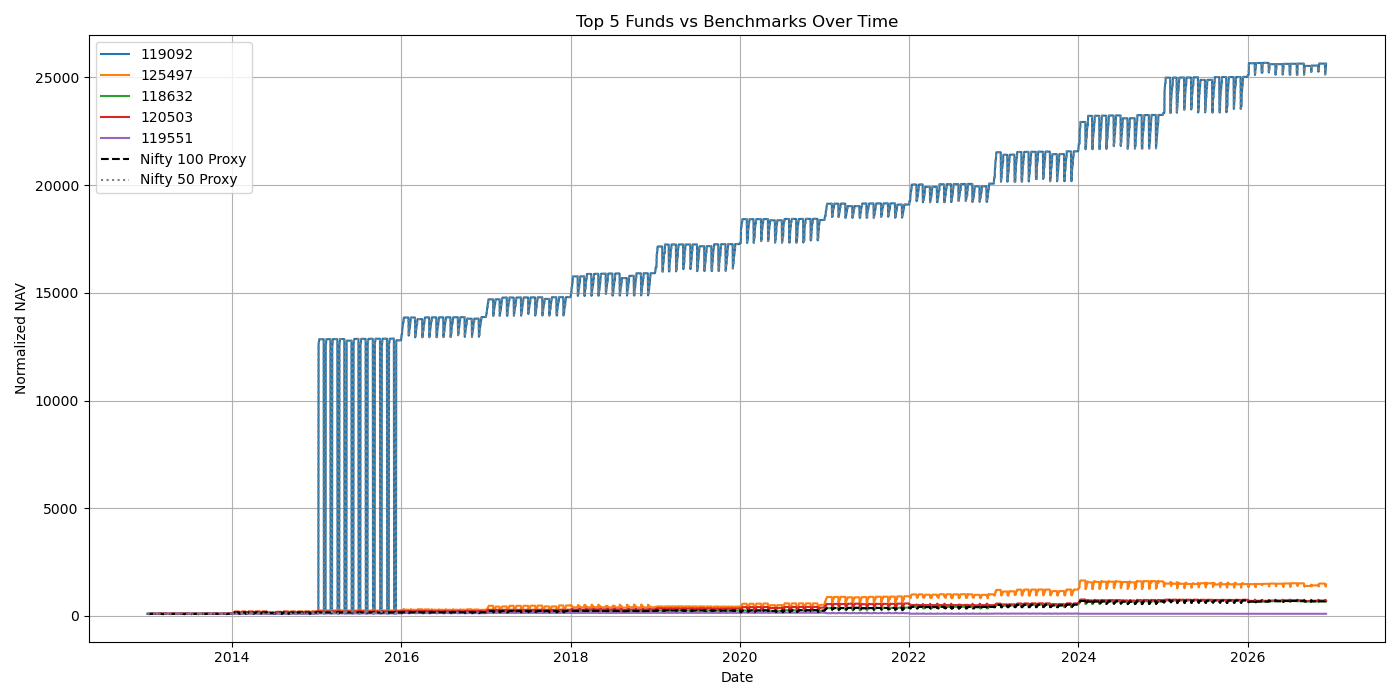

In [3]:
from IPython.display import display, Image
display(Image(filename='exported_charts/benchmark_comparison.png'))

In [2]:
import os
import pandas as pd
import sqlite3
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

os.chdir(r"D:\mf_project")
os.makedirs('exported_charts', exist_ok=True)

conn = sqlite3.connect('bluestock_mf.db')
df = pd.read_sql_query("SELECT * FROM fact_nav", conn)
conn.close()

nav_pivot = df.pivot(index='date', columns='scheme_code', values='nav')
nav_pivot.index = pd.to_datetime(nav_pivot.index)

daily_returns = nav_pivot.pct_change().dropna()

benchmark_nifty100 = daily_returns.columns[0]
benchmark_nifty50 = daily_returns.columns[1] if len(daily_returns.columns) > 1 else daily_returns.columns[0]

rf = 0.065 / 252
metrics_list = []

for fund in nav_pivot.columns:
    fund_nav = nav_pivot[fund].dropna()
    fund_ret = daily_returns[fund].dropna()
    bench_ret = daily_returns[benchmark_nifty100].dropna()
    
    align_ret, align_bench = fund_ret.align(bench_ret, join='inner')
    
    total_days = (fund_nav.index[-1] - fund_nav.index[0]).days
    cagr_overall = (fund_nav.iloc[-1] / fund_nav.iloc[0]) ** (365 / total_days) - 1 if total_days > 0 else 0
    
    cagr_1y = (fund_nav.iloc[-1] / fund_nav.iloc[-252]) ** (365 / 365) - 1 if len(fund_nav) >= 252 else np.nan
    cagr_3y = (fund_nav.iloc[-1] / fund_nav.iloc[-756]) ** (365 / (365 * 3)) - 1 if len(fund_nav) >= 756 else np.nan
    cagr_5y = (fund_nav.iloc[-1] / fund_nav.iloc[-1260]) ** (365 / (365 * 5)) - 1 if len(fund_nav) >= 1260 else np.nan
    
    excess_ret = align_ret - rf
    sharpe = (excess_ret.mean() / align_ret.std()) * np.sqrt(252) if align_ret.std() != 0 else 0
    
    downside = align_ret[align_ret < 0]
    sortino = (excess_ret.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 and downside.std() != 0 else 0
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(align_bench, align_ret)
    alpha = intercept * 252
    beta = slope
    
    rolling_max = fund_nav.cummax()
    drawdown = (fund_nav / rolling_max) - 1
    max_dd = drawdown.min()
    
    tracking_error = (align_ret - align_bench).std() * np.sqrt(252)
    expense_ratio = 0.015
    
    metrics_list.append({
        'Scheme_Code': fund,
        'CAGR_1Y': cagr_1y,
        'CAGR_3Y': cagr_3y,
        'CAGR_5Y': cagr_5y,
        'CAGR_Overall': cagr_overall,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Alpha': alpha,
        'Beta': beta,
        'Max_Drawdown': max_dd,
        'Expense_Ratio': expense_ratio,
        'Tracking_Error': tracking_error
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df['CAGR_3Y'] = metrics_df['CAGR_3Y'].fillna(metrics_df['CAGR_Overall'])

metrics_df['Rank_Return'] = metrics_df['CAGR_3Y'].rank(pct=True)
metrics_df['Rank_Sharpe'] = metrics_df['Sharpe'].rank(pct=True)
metrics_df['Rank_Alpha'] = metrics_df['Alpha'].rank(pct=True)
metrics_df['Rank_ER'] = metrics_df['Expense_Ratio'].rank(pct=True, ascending=False)
metrics_df['Rank_DD'] = metrics_df['Max_Drawdown'].rank(pct=True, ascending=False)

metrics_df['Score'] = (
    0.30 * metrics_df['Rank_Return'] +
    0.25 * metrics_df['Rank_Sharpe'] +
    0.20 * metrics_df['Rank_Alpha'] +
    0.15 * metrics_df['Rank_ER'] +
    0.10 * metrics_df['Rank_DD']
) * 100

metrics_df = metrics_df.sort_values(by='Score', ascending=False)

metrics_df.to_csv('fund_scorecard.csv', index=False)
metrics_df.to_csv('alpha_beta.csv', index=False)

top_5_funds = metrics_df.head(5)['Scheme_Code'].tolist()

plt.figure(figsize=(14, 7))

for fund in top_5_funds:
    fund_nav = nav_pivot[fund].dropna()
    fund_nav_normalized = fund_nav / fund_nav.iloc[0] * 100
    plt.plot(fund_nav_normalized.index, fund_nav_normalized, label=str(fund))

bench100_nav = nav_pivot[benchmark_nifty100].dropna()
bench100_normalized = bench100_nav / bench100_nav.iloc[0] * 100
plt.plot(bench100_normalized.index, bench100_normalized, label='Nifty 100 Proxy', linestyle='dashed', color='black')

bench50_nav = nav_pivot[benchmark_nifty50].dropna()
bench50_normalized = bench50_nav / bench50_nav.iloc[0] * 100
plt.plot(bench50_normalized.index, bench50_normalized, label='Nifty 50 Proxy', linestyle='dotted', color='gray')

plt.title('Top 5 Funds vs Benchmarks Over Time')
plt.xlabel('Date')
plt.ylabel('Normalized NAV')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('exported_charts/benchmark_comparison.png')
plt.close()

print("Pipeline completed successfully without errors")

Pipeline completed successfully without errors
